In [1]:
!sudo apt-get update
!sudo apt-get install p7zip*
!pip install -r requirements.txt
!conda install graph-tool

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://ppa.launchpadcontent.net/git-core/ppa/ubuntu jammy InRelease     
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease             
Hit:5 https://apt.postgresql.org/pub/repos/apt jammy-pgdg InRelease        
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Reading package lists... Done
W: https://apt.postgresql.org/pub/repos/apt/dists/jammy-pgdg/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'p7zip-rar' for glob 'p7zip*'
Note, selecting 'p7zip-full' for glob 'p7zip*'
Note, selecting 'p7zip' for glob 'p7zip*'
p7zip is already the newest version (16.02+dfsg-8).
p7zip-full is already the newest version (16.02+d

In [2]:
import osmnx
import networkx
import solver
import data_management
import data_processing


osmnx.settings.log_console = True
osmnx.settings.use_cache = True

graph = osmnx.graph.graph_from_place("New York", network_type="drive")
graph = osmnx.project_graph(graph)
graph = osmnx.routing.add_edge_speeds(graph)
graph = osmnx.routing.add_edge_travel_times(graph)
graph = networkx.convert_node_labels_to_integers(graph)

In [ ]:
data_management.download_datasets("data")
data_management.clean_datasets("data/FOIL2013")
data_processing.preprocess_datasets(graph, "data/FOIL2013")

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

df = pd.read_parquet("data/FOIL2013/trip_data_1.parquet", engine='fastparquet')
print("Aperçu des données :")
print(df.head())
print (df.columns)

Aperçu des données :
                       hack_license vendor_id  rate_code store_and_fwd_flag  \
0  BA96DE419E711691B9445D6A6307C170       CMT          1                  N   
1  9FD8F69F0804BDB5549F40E9DA1BE472       CMT          1                  N   
2  9FD8F69F0804BDB5549F40E9DA1BE472       CMT          1                  N   
3  51EE87E3205C985EF8431D850C786310       CMT          1                  N   
4  51EE87E3205C985EF8431D850C786310       CMT          1                  N   

      pickup_datetime    dropoff_datetime  passenger_count  trip_time_in_secs  \
0 2013-01-01 15:11:48 2013-01-01 15:18:10                4                382   
1 2013-01-06 00:18:35 2013-01-06 00:22:54                1                259   
2 2013-01-05 18:49:41 2013-01-05 18:54:23                1                282   
3 2013-01-07 23:54:15 2013-01-07 23:58:20                2                244   
4 2013-01-07 23:25:03 2013-01-07 23:34:24                1                560   

   trip_distance 

In [17]:
traffic_data = pd.read_csv("data/automated_traffic_volume_counts.csv")
traffic_data[["HH"]].value_counts()

HH
8     71548
7     71498
9     71494
10    71401
23    71372
22    71364
6     71358
21    71355
20    71353
14    71351
15    71345
17    71341
19    71340
18    71340
13    71339
16    71331
0     71327
12    71316
1     71314
11    71314
2     71308
5     71303
3     71300
4     71293
Name: count, dtype: int64

In [18]:
traffic_data[["Vol"]].value_counts()

Vol  
 0       92906
 1       23098
 2       23007
 3       22151
 4       21516
         ...  
 5425        1
-1           1
 4609        1
 4612        1
 4621        1
Name: count, Length: 3069, dtype: int64

In [19]:
traffic_data.head()

,RequestID,Boro,Yr,M,D,HH,MM,Vol,SegmentID,WktGeom,street,fromSt,toSt,Direction
0,32970,Queens,2021,4,30,2,0,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB
1,32970,Queens,2021,4,30,2,15,1,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB
2,32970,Queens,2021,4,30,2,30,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB
3,32970,Queens,2021,4,30,2,45,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB
4,32970,Queens,2021,4,30,3,0,1,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB


In [20]:
traffic_data[['WktGeom']].dtypes

WktGeom    object
dtype: object

In [21]:
df.columns

Index(['hack_license', 'vendor_id', 'rate_code', 'store_and_fwd_flag',
       'pickup_datetime', 'dropoff_datetime', 'passenger_count',
       'trip_time_in_secs', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'pickup_nearest_node', 'dropoff_nearest_node'],
      dtype='object')

In [23]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day_name()  # Jour de la semaine
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_date'] = df['pickup_datetime'].dt.date  # Date sans l'heure

/tmp/ipykernel_237105/185834521.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_trips.index, y=hourly_trips.values, palette="viridis")


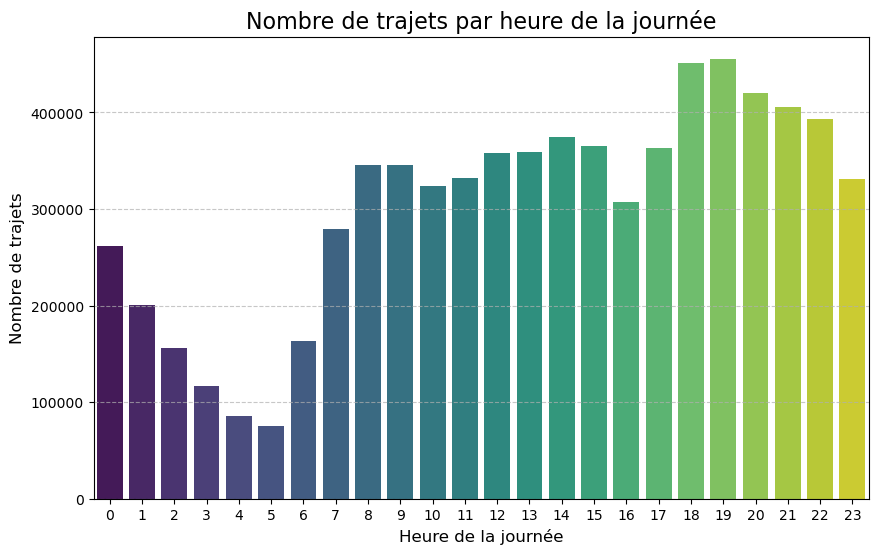

In [24]:
hourly_trips = df['pickup_hour'].value_counts().sort_index()

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_trips.index, y=hourly_trips.values, palette="viridis")
plt.title("Nombre de trajets par heure de la journée", fontsize=16)
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_237105/2072531354.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_trips.index, y=weekly_trips.values, palette="pastel")


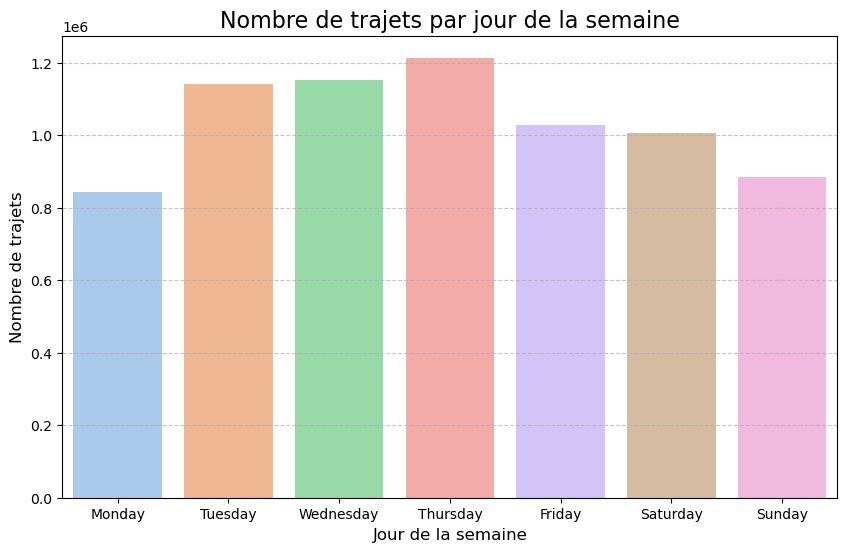

In [25]:
# Compter les trajets par jour de la semaine
weekly_trips = df['pickup_day'].value_counts()

# Ordonner les jours de la semaine
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_trips = weekly_trips.reindex(ordered_days)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=weekly_trips.index, y=weekly_trips.values, palette="pastel")
plt.title("Nombre de trajets par jour de la semaine", fontsize=16)
plt.xlabel("Jour de la semaine", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

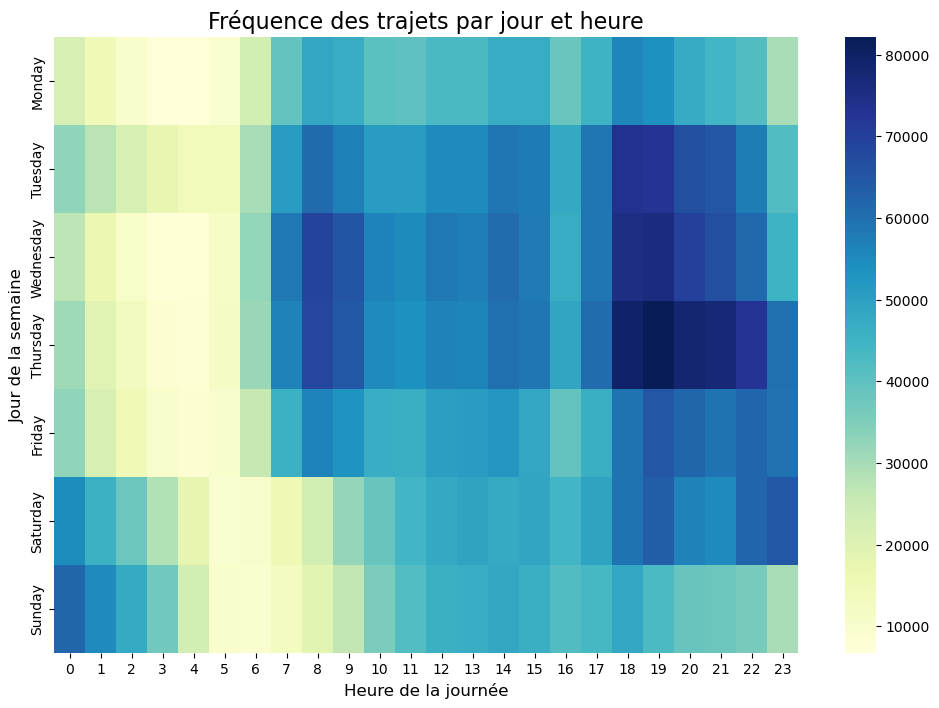

In [26]:
# Grouper les trajets par jour de la semaine et heure
heatmap_data = df.groupby(['pickup_day', 'pickup_hour']).size().unstack()

# Réordonner les jours
heatmap_data = heatmap_data.reindex(index=ordered_days)

# Visualisation
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Fréquence des trajets par jour et heure", fontsize=16)
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Jour de la semaine", fontsize=12)
plt.show()

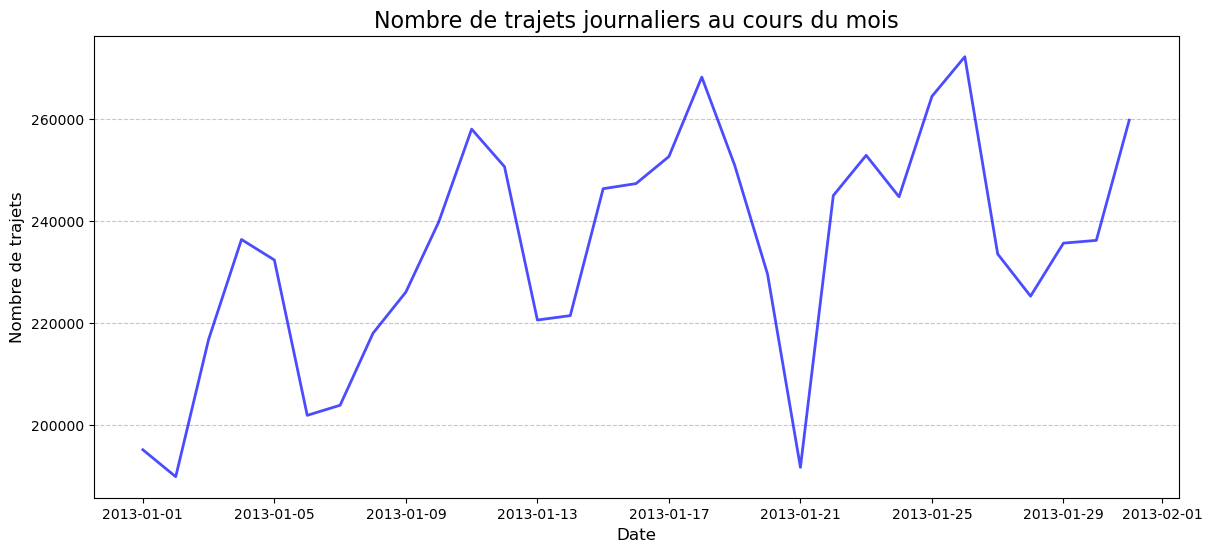

In [27]:
# Compter les trajets par jour du mois
daily_trips = df.groupby('pickup_date').size()

# Visualisation
plt.figure(figsize=(14, 6))
daily_trips.plot(color="blue", alpha=0.7, linewidth=2)
plt.title("Nombre de trajets journaliers au cours du mois", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [31]:
# Renommer les colonnes pour qu'elles soient explicites
traffic_data = traffic_data.rename(columns={'Yr': 'year', 'M': 'month', 'D': 'day', 'HH' : 'hour', 'MM' : 'minute'})

# Vérification des colonnes
print(traffic_data.columns)

Index(['RequestID', 'Boro', 'year', 'month', 'day', 'hour', 'minute', 'Vol',
       'SegmentID', 'WktGeom', 'street', 'fromSt', 'toSt', 'Direction',
       'datetime'],
      dtype='object')


In [32]:
# Conversion en datetime
traffic_data['datetime'] = pd.to_datetime(traffic_data[['year', 'month', 'day', 'hour', 'minute']])
print(traffic_data[['year', 'month', 'day', 'datetime']].head())


   year  month  day            datetime
0  2021      4   30 2021-04-30 02:00:00
1  2021      4   30 2021-04-30 02:15:00
2  2021      4   30 2021-04-30 02:30:00
3  2021      4   30 2021-04-30 02:45:00
4  2021      4   30 2021-04-30 03:00:00


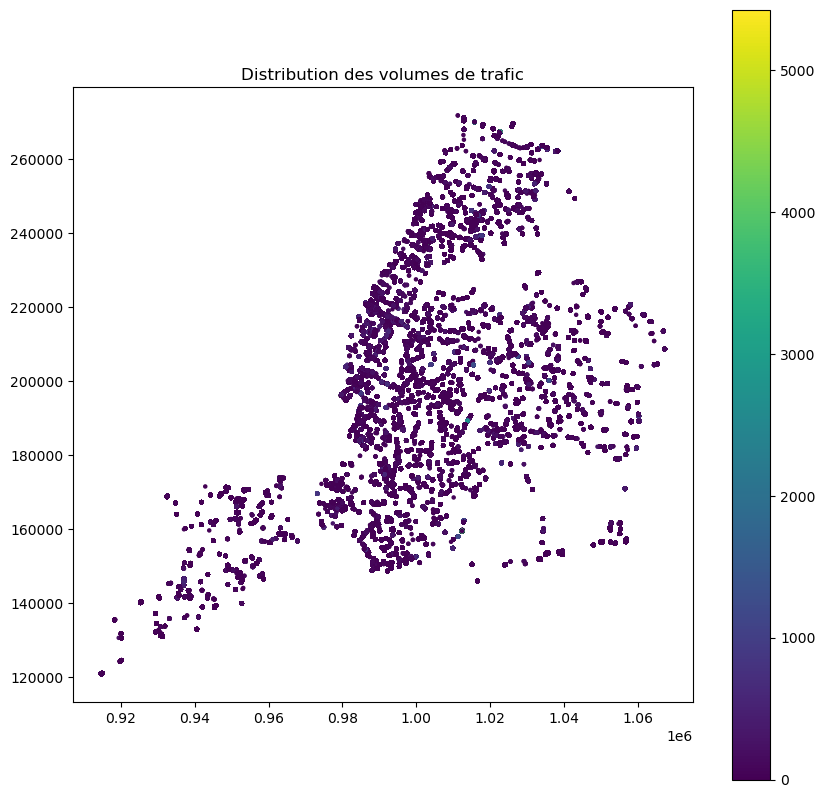

In [33]:
import geopandas as gpd
from shapely import wkt

traffic_data['geometry'] = traffic_data['WktGeom'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(traffic_data, geometry='geometry')
ax = gdf.plot(column='Vol', legend=True, cmap='viridis', markersize=5, figsize=(10, 10))
plt.title('Distribution des volumes de trafic')
plt.show()

In [34]:
if gdf.crs is None:
    # Si le CRS n'est pas défini, on l'assigne manuellement à EPSG:4326 (latitude/longitude)
    gdf.set_crs("EPSG:2263", allow_override=True, inplace=True)
elif gdf.crs != "EPSG:2263":
    # Si le CRS est défini mais n'est pas EPSG:4326, on le convertit
    gdf = gdf.to_crs("EPSG:2263")

# Agrégation des données par rue
agg_gdf = gdf.groupby('street').agg({
    'Vol': 'sum',  # Somme des volumes de trafic
    'geometry': 'first'  # Garder la première géométrie (généralement le centroïde)
}).reset_index()


# Agrégation par "street"
aggregated_df = traffic_data.groupby('street').agg(
    Vol=('Vol', 'sum'),  # Additionner les volumes
    Boro=('Boro', 'first'),  # Prendre la première valeur pour "Boro"
    SegmentID=('SegmentID', 'first'),  # Prendre la première valeur pour "SegmentID"
    WktGeom=('WktGeom', 'first'),  # Prendre la première valeur pour "WktGeom"
    fromSt=('fromSt', 'first'),  # Prendre la première valeur pour "fromSt"
    toSt=('toSt', 'first'),  # Prendre la première valeur pour "toSt"
    Direction=('Direction', 'first'),  # Prendre la première valeur pour "Direction"
    datetime=('datetime', 'min')  # Prendre la première date (vous pouvez utiliser 'min' ou 'max' selon vos besoins)
).reset_index()

In [35]:
traffic_data

,RequestID,Boro,year,month,day,hour,minute,Vol,SegmentID,WktGeom,street,fromSt,toSt,Direction,datetime,geometry
0,32970,Queens,2021,4,30,2,0,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,2021-04-30 02:00:00,POINT (997407.0998491726 208620.92612708386)
1,32970,Queens,2021,4,30,2,15,1,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,2021-04-30 02:15:00,POINT (997407.0998491726 208620.92612708386)
2,32970,Queens,2021,4,30,2,30,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,2021-04-30 02:30:00,POINT (997407.0998491726 208620.92612708386)
3,32970,Queens,2021,4,30,2,45,0,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,2021-04-30 02:45:00,POINT (997407.0998491726 208620.92612708386)
4,32970,Queens,2021,4,30,3,0,1,149701,POINT (997407.0998491726 208620.92612708386),PULASKI BRIDGE,Newtown Creek Shoreline,Dead end,NB,2021-04-30 03:00:00,POINT (997407.0998491726 208620.92612708386)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712600,17447,Queens,2014,6,28,15,0,6,90610,POINT (1037356.1 200863.7),PARSONS BLVD,VILLAGE RD,GOETHALS AV,WB,2014-06-28 15:00:00,POINT (1037356.1 200863.7)
1712601,17447,Queens,2014,6,28,15,15,7,90610,POINT (1037356.1 200863.7),PARSONS BLVD,VILLAGE RD,GOETHALS AV,WB,2014-06-28 15:15:00,POINT (1037356.1 200863.7)
1712602,17447,Queens,2014,6,28,15,30,8,90610,POINT (1037356.1 200863.7),PARSONS BLVD,VILLAGE RD,GOETHALS AV,WB,2014-06-28 15:30:00,POINT (1037356.1 200863.7)
1712603,17447,Queens,2014,6,28,15,45,8,90610,POINT (1037356.1 200863.7),PARSONS BLVD,VILLAGE RD,GOETHALS AV,WB,2014-06-28 15:45:00,POINT (1037356.1 200863.7)


In [36]:
from folium import Choropleth
from IPython.display import IFrame


m = folium.Map(location=[40.7128, -74.0060], zoom_start=12)

for idx, row in agg_gdf.iterrows():
    # Utiliser le centroïde de la géométrie pour le placement du cercle
    if row['geometry'].is_valid:  # Vérifier la validité de la géométrie
        centroid = row['geometry'].centroid
        traffic_volume = row['Vol']
        radius = min(traffic_volume / 100, 50)  # La taille du cercle est proportionnelle au volume de trafic, avec un maximum de rayon de 50

        # Ajouter un cercle sur la carte
        folium.CircleMarker(
            location=[centroid.y, centroid.x],  # Utiliser le centroïde de la géométrie pour le placement du cercle
            radius=radius,  # Taille du cercle
            color='blue',  # Couleur du cercle
            fill=True,
            fill_color='blue',  # Couleur de remplissage
            fill_opacity=0.6,  # Opacité du remplissage
            tooltip=f"Street: {row['street']}<br>Traffic Volume: {traffic_volume}"  # Tooltip pour chaque cercle
        ).add_to(m)

# Afficher la carte directement dans le notebook
m

In [40]:
import numpy as np

dates = pd.DataFrame({"start": [np.datetime64("2013-01-01")], "end": [np.datetime64("2013-12-31")]})
od_demand = data_processing.build_raw_od_matrix("data/FOIL2013", dates, graph.order())

In [65]:
lanes = []
maxspeeds = []
lengths = []
nodes = []
travel_times = []

for u, v, data in graph.edges(data=True):
    nodes.append((u, v))
    if "lanes" in data:
        if isinstance(data["lanes"], list):
            lanes.append(float(data["lanes"][0]))
        else:
            lanes.append(float(data["lanes"]))
    else:
        lanes.append(np.nan)
    travel_times.append(float(data.get("travel_time", np.nan)))
    maxspeeds.append(float(data.get("speed_kph", np.nan)))
    lengths.append(float(data.get("length", np.nan)))

data_edges = pd.DataFrame(data = {"lanes": lanes, "maxspeed": maxspeeds, "length": lengths, "travel_time": travel_times}, index = pd.MultiIndex.from_tuples(nodes, names=["u", "v"]))


In [71]:
for row in data_edges.itertuples(index=True, name='Pandas'):
    print(f"Index: {row.Index}, Row: {row.lanes}")
    break

Index: (0, 1), Row: 2.0


In [66]:
for col in data_edges.columns:
    data_edges[data_edges[col].isna()] = data_edges[col].mean()
data_edges["capacity"] = data_edges["length"] / (4.48 + data_edges["maxspeed"] * 6)

In [79]:
import graph_tool.all as gt
import networkx as nx

a = 0.15
b = 4

gt_graph = gt.Graph(nx.to_scipy_sparse_array(graph))
A, B, C, T0, back = [gt_graph.new_edge_property("float") for _ in range(5)]
num_edges = gt_graph.num_edges()

A.a = a * np.ones(num_edges)
B.a = b * np.ones(num_edges)

for row in data_edges.itertuples(index=True, name='Pandas'):
    edge = gt_graph.edge(*row.Index)
    C[edge] = row.capacity
    T0[edge] = row.travel_time

params = [A, B, C, T0]
demand_coo = od_demand.tocoo()
demand  = {(r, c): v for r, c, v in zip(demand_coo.row, demand_coo.col, demand_coo.data)}

itapas_solver = solver.ITAPAS(gt_graph, params, back, solver.bpr_function)

In [ ]:
link_flow, link_flow_node = itapas_solver.assign(demand)